In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Morphology

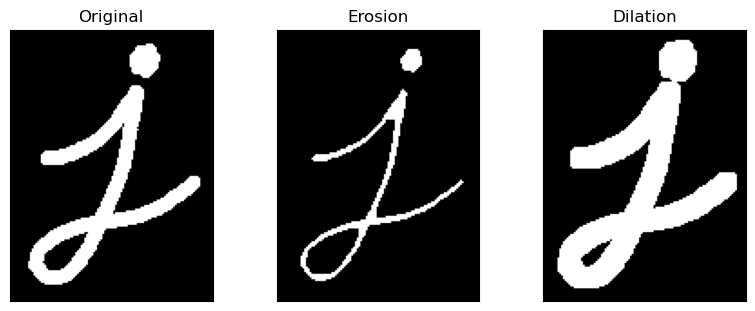

In [2]:
j = cv2.imread("img/j.png")

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(j, kernel, iterations=1)
dilation = cv2.dilate(j, kernel, iterations=1)

images = [j, erosion, dilation]
titles = ["Original", "Erosion", "Dilation"]

_, axes = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], "gray")
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-morph-border.png")

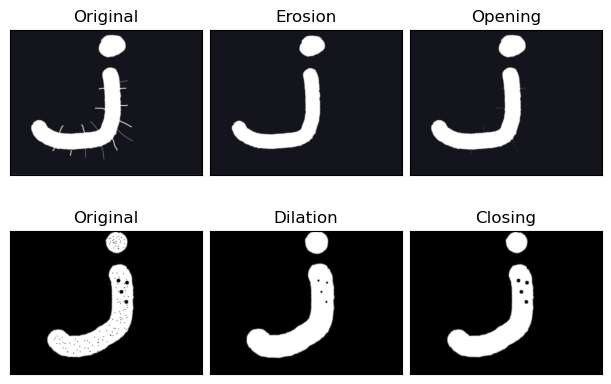

In [3]:
jo = cv2.imread("img/j-open.png")
jc = cv2.imread("img/j-close.png")

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(jo, kernel, iterations=1)
dilation = cv2.dilate(jc, kernel, iterations=1)

opening = cv2.morphologyEx(jo, cv2.MORPH_OPEN, kernel, iterations=1)
closing = cv2.morphologyEx(jc, cv2.MORPH_CLOSE, kernel, iterations=1)

images = [jo, erosion, opening, jc, dilation, closing]
titles = ["Original", "Erosion", "Opening", "Original", "Dilation", "Closing"]

_, axes = plt.subplots(2, 3, figsize=(6, 4), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], "gray")
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-morph-combination.png")

## Gradient

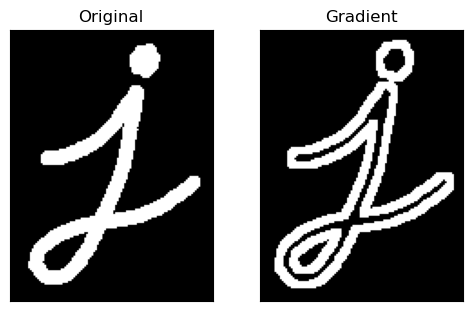

In [4]:
j = cv2.imread("img/j.png")

kernel = np.ones((5, 5), np.uint8)
gradient = cv2.morphologyEx(j, cv2.MORPH_GRADIENT, kernel)

images = [j, gradient]
titles = ["Original", "Gradient"]

_, axes = plt.subplots(1, 2, figsize=(5, 3), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], "gray")
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-morph-gradient.png")

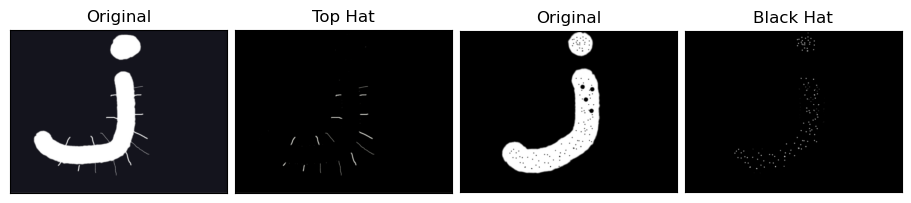

In [5]:
jo = cv2.imread("img/j-open.png")
jc = cv2.imread("img/j-close.png")

kernel = np.ones((5, 5), np.uint8)
jot = cv2.morphologyEx(jo, cv2.MORPH_TOPHAT, kernel, iterations=1)
jcb = cv2.morphologyEx(jc, cv2.MORPH_BLACKHAT, kernel, iterations=1)

images = [jo, jot, jc, jcb]
titles = ["Original", "Top Hat", "Original", "Black Hat"]

_, axes = plt.subplots(1, 4, figsize=(9, 2), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], "gray")
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-morph-hat.png")

## Sobel

FileNotFoundError: [Errno 2] No such file or directory: '../images/opencv-sobel.png'

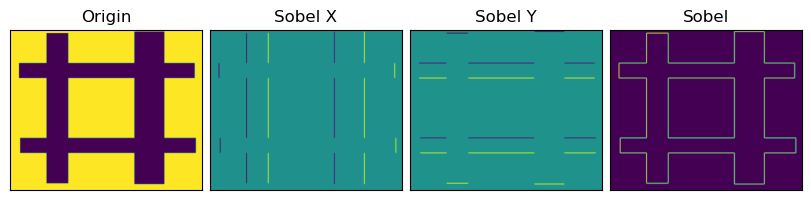

In [6]:
img = "img/sharp.png"
src = cv2.imread(img, 0)
sobel_x = cv2.Sobel(src, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(src, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)

imgs = [src, sobel_x, sobel_y, sobel]
titles = ["Origin", "Sobel X", "Sobel Y", "Sobel"]

_, axes = plt.subplots(1, len(imgs), figsize=(8, 2), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

plt.savefig("../images/opencv-sobel.png")

## Scharr

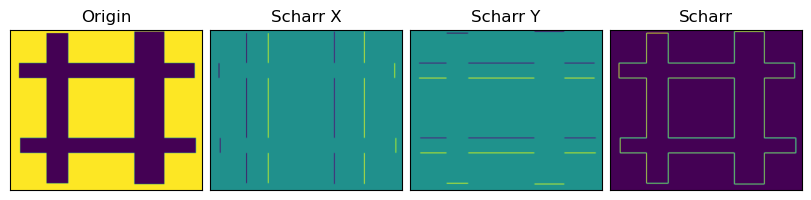

In [ ]:
img = "img/sharp.png"
src = cv2.imread(img, 0)
scharr_x = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=1, dy=0)
scharr_y = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=0, dy=1)
scharr = np.sqrt(scharr_x**2 + scharr_y**2)

imgs = [src, scharr_x, scharr_y, scharr]
titles = ["Origin", "Scharr X", "Scharr Y", "Scharr"]

_, axes = plt.subplots(1, len(imgs), figsize=(8, 2), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-scharr.png")

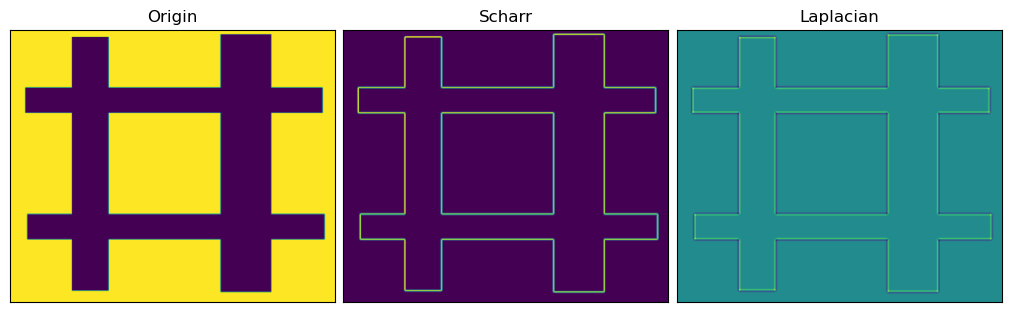

In [ ]:
img = "img/sharp.png"
src = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
scharr_x = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=1, dy=0)
scharr_y = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=0, dy=1)
scharr = np.sqrt(scharr_x**2 + scharr_y**2)
# Apply LoG filter
filtered_img = cv2.GaussianBlur(src, (3, 3), 1)
filtered_img = cv2.Laplacian(filtered_img, cv2.CV_64F)
# Normalize the filtered image
laplacian = cv2.normalize(
    filtered_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
)
imgs = [src, scharr, laplacian]
titles = ["Origin", "Scharr", "Laplacian"]

_, axes = plt.subplots(1, len(imgs), figsize=(10, 3), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-laplacian.png")

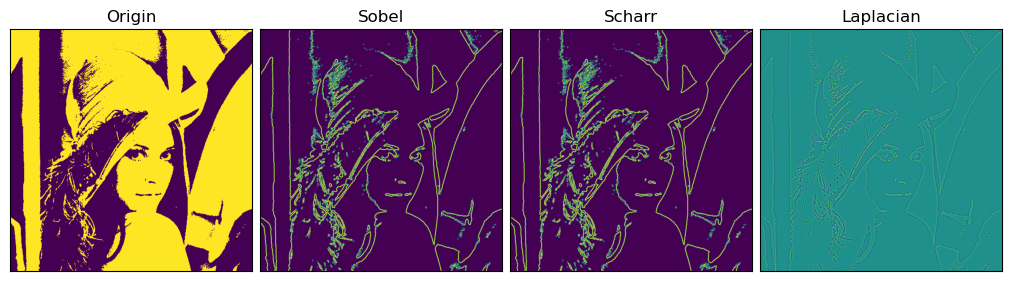

In [ ]:
src = cv2.imread("img/lena.png", cv2.IMREAD_GRAYSCALE)
_, src = cv2.threshold(src, 127, 255, cv2.THRESH_BINARY)

sobel_x = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=1, dy=0)
sobel_y = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=0, dy=1)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)
scharr_x = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=1, dy=0)
scharr_y = cv2.Scharr(src, ddepth=cv2.CV_64F, dx=0, dy=1)
scharr = np.sqrt(scharr_x**2 + scharr_y**2)
# Apply LoG filter
filtered_img = cv2.GaussianBlur(src, (3, 3), 1)
filtered_img = cv2.Laplacian(filtered_img, cv2.CV_64F)
# Normalize the filtered image
laplacian = cv2.normalize(
    filtered_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
)
imgs = [src, sobel, scharr, laplacian]
titles = ["Origin", "Sobel", "Scharr", "Laplacian"]

_, axes = plt.subplots(1, len(imgs), figsize=(10, 3), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-laplacian.png")

## Canny

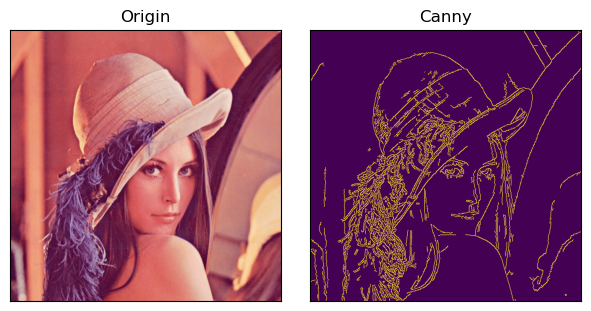

In [ ]:
src = cv2.imread("img/lena.png", cv2.IMREAD_COLOR_RGB)
canny = cv2.Canny(src, threshold1=100, threshold2=200)
imgs = [src, canny]
titles = ["Origin", "Canny"]

_, axes = plt.subplots(1, len(imgs), figsize=(6, 3), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-canny.png")

## Hough

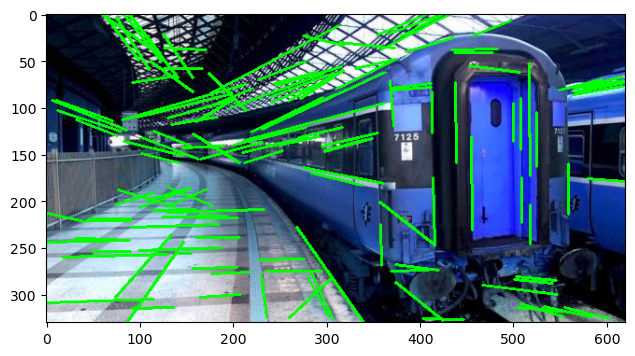

In [ ]:
img = cv2.imread("img/houghlines5.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 120)

lines = cv2.HoughLinesP(
    edges, rho=1, theta=np.pi / 180.0, threshold=20, minLineLength=40, maxLineGap=5
)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

_, ax = plt.subplots(figsize=(8, 4))
ax.imshow(edges)
ax.imshow(img)

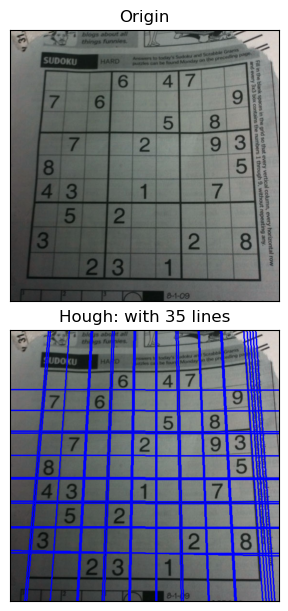

In [ ]:
img = cv2.imread("img/sudoku.png")
src = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 10, 50, apertureSize=3)

lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

for line in lines:
    ρ, θ = line[0]
    a, b = np.cos(θ), np.sin(θ)
    x0, y0 = a * ρ, b * ρ
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    img = cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)


imgs = [src, img]
titles = ["Origin", f"Hough: with {len(lines)} lines"]
_, axes = plt.subplots(len(imgs), 1, figsize=(3, 6), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-hough.png")

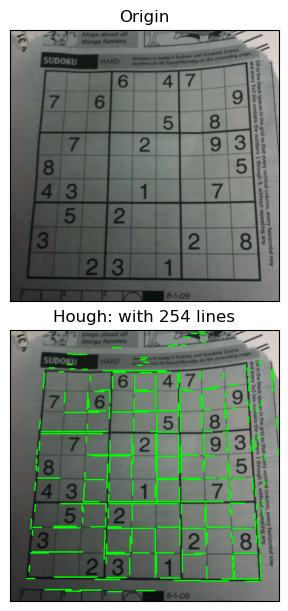

In [ ]:
img = cv2.imread("img/sudoku.png")
src = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

minLineLength = 100
maxLineGap = 10

lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength, maxLineGap)

for line in lines:
    x1, y1, x2, y2 = line[0]
    img = cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

imgs = [src, img]
titles = ["Origin", f"Hough: with {len(lines)} lines"]
_, axes = plt.subplots(len(imgs), 1, figsize=(3, 6), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-houghp.png")

### Hough Circle

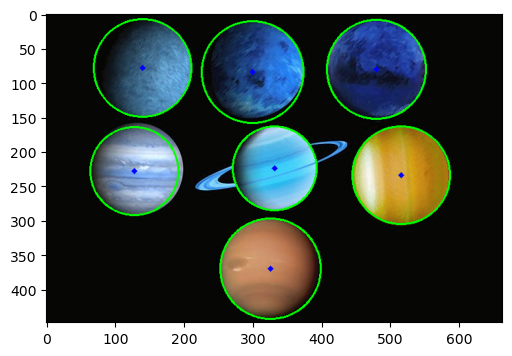

In [ ]:
planets = cv2.imread("img/planet_glow.jpg")
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
gray_img = cv2.medianBlur(gray_img, 5)

circles = cv2.HoughCircles(
    gray_img, cv2.HOUGH_GRADIENT, 1, 120, param1=90, param2=40, minRadius=0, maxRadius=0
)

if circles is not None:
    circles = np.uint16(np.around(circles))

    for i in circles[0, :]:
        # draw the outer circle
        cv2.circle(planets, (i[0], i[1]), i[2], (0, 255, 0), 2)
        # draw the center of the circle
        cv2.circle(planets, (i[0], i[1]), 2, (0, 0, 255), 3)

_, ax = plt.subplots(figsize=(8, 4))
ax.imshow(planets)

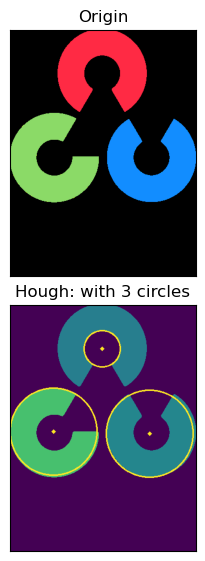

In [ ]:
img = cv2.imread("img/opencv-logo.png", cv2.IMREAD_COLOR_RGB)
src = img.copy()
img = cv2.medianBlur(img, 5)
cimg = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

circles = cv2.HoughCircles(
    cimg, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=0, maxRadius=0
)

circles = np.uint16(np.around(circles))

for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(cimg, (i[0], i[1]), i[2], (255, 0, 0), 2)
    # draw the center of the circle
    cimg = cv2.circle(cimg, (i[0], i[1]), 2, (255, 0, 0), 3)

imgs = [src, cimg]
titles = ["Origin", f"Hough: with {len(circles[0, :])} circles"]
_, axes = plt.subplots(len(imgs), 1, figsize=(2.25, 5.5), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-hough-logo.png")

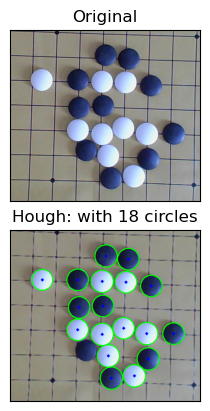

In [ ]:
from collections import Counter

import cv2
import numpy as np


def detect_pawn(img):
    txt = "black"
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, threshold = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    c = Counter(list(threshold.flatten()))
    if c.most_common()[0][0] != 0:
        txt = "white"
    return txt, threshold


img = cv2.imread("img/go.png", cv2.IMREAD_COLOR_RGB)
src = img.copy()

img = cv2.medianBlur(img, 5)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

circles = cv2.HoughCircles(
    gray, cv2.HOUGH_GRADIENT, 1, 20, param1=100, param2=30, minRadius=10, maxRadius=50
)

if circles is None:
    exit(-1)

circles = np.uint16(np.around(circles))

font = cv2.FONT_HERSHEY_SIMPLEX
for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)
    # draw the center of the circle
    cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)

    x, y, r = i
    crop_img = img[y - r : y + r, x - r : x + r]
    # 检测围棋
    txt, threshold = detect_pawn(crop_img)

    cv2.putText(
        threshold,
        text=txt,
        org=(0, 0),
        fontFace=font,
        fontScale=0.5,
        color=(0, 255, 0),
        thickness=2,
    )

imgs = [src, img]
titles = ["Original", f"Hough: with {len(circles[0, :])} circles"]
_, axes = plt.subplots(len(imgs), 1, figsize=(2.25, 4), constrained_layout=1)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set(title=titles[i], xticks=[], yticks=[])

# plt.savefig("../images/opencv-hough-go.png")